# Volve Field — Well Trajectory Reconstruction from EOWR Survey Reports

This notebook rebuilds 3D well trajectories for wells **15/9-F-14** and **15/9-F-15 D** (Volve field, Equinor/Statoil open dataset) directly from the directional-drilling End of Well Reports (EOWR).

**Approach**
1. Pull the *Survey Report – Geographic* table out of each well's EOWR PDF with `tabula-py`.
2. Clean the extracted values (Norwegian decimal-comma formatting, embedded units, degree/minute/second coordinates).
3. Feed the MD / Inclination / Azimuth (minimum-curvature survey) into `welly` to compute a 3D position log.
4. Plot both wellbores together in 3D, plus a plan view and a vertical section — the two views directional drillers use day to day.

**Adapted from:** [
Exploratory Data Analysis of Volve North Sea Asset in Python - Session 1 - Part 2](https://www.youtube.com/watch?v=KZalQ02aEHQ&list=PL_pV2V5A8D8GA7khlrQ1m1MVZqpCyrNi5&index=4)

## 1. Setup

In [1]:
!pip install -q tabula-py welly JPype1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tabula
import pandas as pd
import numpy as np
import welly

import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from mpl_toolkits.mplot3d import Axes3D

import warnings
import logging

# Suppress tabula-py / Java backend logs so the extraction cells stay readable
logging.getLogger('tabula.backend').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

## 2. Well / file configuration

> **If you're running this in Google Colab:** upload both PDFs and set `DATA_DIR = "/content"`. If you're running it locally / on this notebook's original machine, point `DATA_DIR` at the folder holding the two report PDFs.

### A note on the page numbers
Both EOWRs contain **several** survey-style tables (drilling-parameter charts, magnetics reference tables, error-ellipse reports, etc.) — not every table on every page is the deviation survey. The pages below were confirmed by searching each PDF's text layer for `"Survey Report - Geographic"` and `"Dogleg"`:

| Well | Pages used | What's actually there |
|---|---|---|
| 15/9-F-15 D | 62–64 | *Survey Report – Geographic* (MD, Inc, Azi, TVD, N/S, E/W, Northing, Easting, Lat, Long) |
| 15/9-F-14 | 74–75 | Same report type, same 10-column layout |

In [4]:
DATA_DIR = "/content/drive/MyDrive/PetE/ML for PetE/Volve production data/EDA of Volve North Sea Asset - Orkahub/Well_logs/14. Div Report"

wells_info = {
    '15-9-F-15': {
        'path': f"{DATA_DIR}/15-9-F-15 D_EOWR_Logging mudlogging direction drilling_BH.pdf",
        'pages': np.arange(62, 65),   # 62, 63, 64
    },
    '15-9-F-14': {
        'path': f"{DATA_DIR}/15-9-f-14_nr_002_MWD_DD_EOWR.pdf",
        'pages': [74, 75],
    },
}

wells_info

{'15-9-F-15': {'path': '/content/drive/MyDrive/PetE/ML for PetE/Volve production data/EDA of Volve North Sea Asset - Orkahub/Well_logs/14. Div Report/15-9-F-15 D_EOWR_Logging mudlogging direction drilling_BH.pdf',
  'pages': array([62, 63, 64])},
 '15-9-F-14': {'path': '/content/drive/MyDrive/PetE/ML for PetE/Volve production data/EDA of Volve North Sea Asset - Orkahub/Well_logs/14. Div Report/15-9-f-14_nr_002_MWD_DD_EOWR.pdf',
  'pages': [74, 75]}}

## 3. Quick look at the raw extraction

`tabula` typically mis-detects the first row of these tables as a header row, so column names end up being the first survey station's *values* (e.g. `'2 711,40'`) rather than real names like `MD`. We work around this later by stacking the column names back in as the first data row. For now, just confirm the extraction picks up a sensible-looking table.

In [5]:
preview = tabula.read_pdf(wells_info['15-9-F-15']['path'], pages='62', multiple_tables=True)
preview[-1].head(10)

,"0,00","0,00.1","0,00.2","0,00.3","-3,17","3,53","6 478 560,36","435 053,55","58° 26' 29,706 N","1° 53' 15,149 E"
0,"145,90","0,00","360,00","145,90","-3,17","3,53","6 478 560,36","435 053,55","58° 26' 29,706 N","1° 53' 15,149 E"
1,"153,40","0,15","253,69","153,40","-3,17","3,52","6 478 560,36","435 053,54","58° 26' 29,706 N","1° 53' 15,149 E"
2,"234,20","0,28","146,02","234,20","-3,37","3,53","6 478 560,16","435 053,55","58° 26' 29,700 N","1° 53' 15,150 E"
3,"274,60","0,78","136,21","274,60","-3,65","3,78","6 478 559,88","435 053,80","58° 26' 29,691 N","1° 53' 15,165 E"
4,"315,00","1,46","128,29","314,99","-4,16","4,37","6 478 559,37","435 054,39","58° 26' 29,675 N","1° 53' 15,202 E"
5,"355,30","3,41","124,07","355,25","-5,15","5,77","6 478 558,38","435 055,79","58° 26' 29,643 N","1° 53' 15,289 E"
6,"395,70","5,13","126,98","395,54","-6,91","8,21","6 478 556,62","435 058,22","58° 26' 29,588 N","1° 53' 15,441 E"
7,"436,10","5,52","139,07","435,76","-9,47","10,92","6 478 554,06","435 060,94","58° 26' 29,507 N","1° 53' 15,611 E"


## 4. Cleaning function

Values in the source tables come out of `tabula` as strings in Norwegian formatting (`"1 364,50"` = 1364.50, i.e. space as thousands separator, comma as decimal point). Some cells also contain non-numeric survey annotations we want to drop:

- bit sizes like `12 1/4"` → excluded (`"` present)
- tool/run labels like `30"` → excluded
- latitude/longitude in degrees-minutes-seconds (`58° 26' 29,706" N`) → kept as text, since we don't need them for the trajectory plot
- everything else → converted to a proper Python `float`

In [6]:
def clean_value(x):
    """Convert one cell of the raw tabula extraction into a usable value."""
    if isinstance(x, float):
        return x
    elif "'" in x:
        return x                 # DMS lat/long text -- keep as-is, not needed for the plot
    elif '"' in x:
        return np.nan             # bit sizes / annotations, e.g. 12 1/4"
    elif ':' in x:
        return np.nan             # time-of-day style annotations
    else:
        x = x.replace(' ', '')    # strip thousands-separator spaces
        x = x.replace('.', '')    # strip thousands-separator dots (if any)
        x = x.replace(',', '.')   # Norwegian decimal comma -> decimal point
        return float(x)

## 5. Extract, clean, and assemble the survey table for each well

For each well we read every configured page, glue the tables together (recovering the header row that `tabula` swallowed), clean every cell, and drop rows that aren't real survey stations. The columns we actually need, by position, are:

| Index | Field |
|---|---|
| 0 | Measured Depth (MD), m |
| 1 | Inclination, ° |
| 2 | Azimuth, ° |
| 3 | True Vertical Depth (TVD), m |
| 6 | Northing (UTM), m |
| 7 | Easting (UTM), m |

**Data-quality fix:** a few survey rows report azimuth as exactly `360.00°` instead of `0.00°` (both mean the same heading at zero/near-zero inclination). `welly`'s underlying survey math requires `0 <= azimuth < 360`, so we normalize with `% 360` before handing the array off.

In [7]:
def build_well_survey(name, path, pages):
    df = pd.DataFrame()
    for page in pages:
        tables = tabula.read_pdf(path, pages=str(page), multiple_tables=True)
        table = tables[-1]
        # tabula misread the first data row as the header -- stack it back in as real data
        table = pd.DataFrame(np.vstack([table.columns, table]))
        df = pd.concat([df, table], axis=0, ignore_index=True)

    df = df.map(clean_value)
    df = df.dropna(subset=[0, 1, 2, 3, 6, 7])   # keep only complete survey stations
    df = df.reset_index(drop=True)

    # Datum: Northing, Easting, TVD of the first surveyed station
    datum_row = df.loc[0, [6, 7, 3]].to_numpy()
    datum = [int(datum_row[0]), int(datum_row[1]), datum_row[2]]

    # MD / Inclination / Azimuth for the minimum-curvature survey
    deviation = np.array(df.loc[:, [0, 1, 2]].to_numpy(), dtype=float, copy=True)
    deviation[:, 2] = deviation[:, 2] % 360   # normalize 360.00 deg -> 0.00 deg

    print(f"{name}: {len(df)} survey stations, MD range {deviation[0,0]:.1f}-{deviation[-1,0]:.1f} m")

    return {'well_name': name, 'survey_df': df, 'deviation': deviation, 'datum': datum}

In [8]:
well_surveys = [
    build_well_survey(name, info['path'], info['pages'])
    for name, info in wells_info.items()
]

15-9-F-15: 115 survey stations, MD range 0.0-4685.0 m
15-9-F-14: 99 survey stations, MD range 145.9-3750.0 m


## 6. Build the 3D position log with `welly`

`welly.Location.add_deviation()` runs the minimum-curvature calculation on the MD/Inc/Azi triples; `trajectory(datum=..., elev=True)` returns the resulting XYZ path anchored at each well's surface datum.

In [9]:
for ws in well_surveys:
    z = welly.Well()
    z.location = welly.Location(params={'kb': 0})
    z.location.add_deviation(ws['deviation'])
    ws['location'] = z.location


## 7. 3D trajectory plot

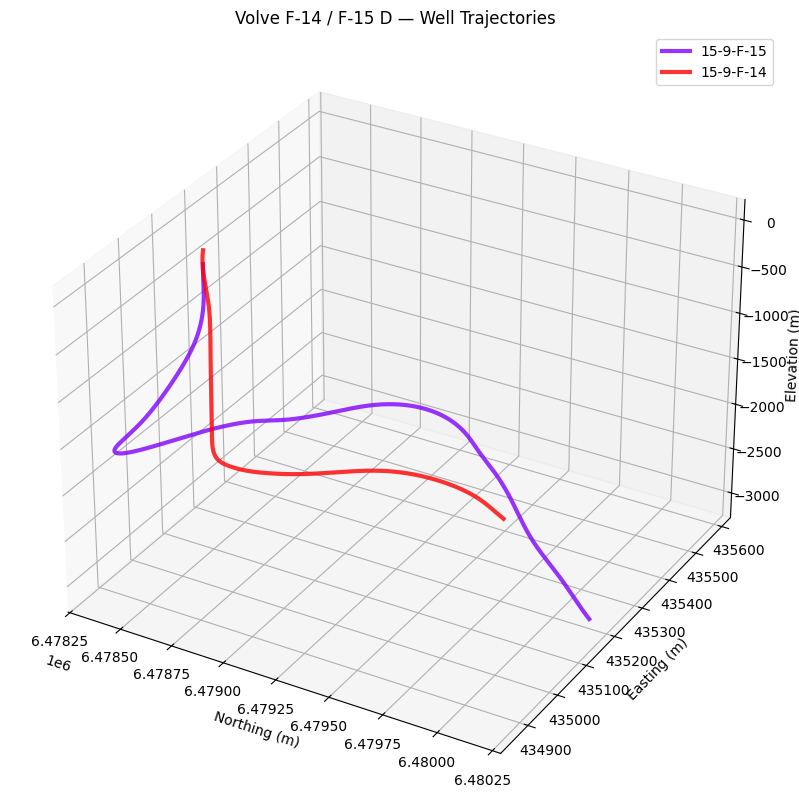

In [10]:
color = cm.rainbow(np.linspace(0, 1, len(well_surveys)))

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(projection='3d')

for i, ws in enumerate(well_surveys):
    traj = ws['location'].trajectory(datum=ws['datum'], elev=True)
    ax.plot(*traj.T, lw=3, alpha=0.8, color=color[i], label=ws['well_name'])

ax.set_xlabel('Northing (m)')
ax.set_ylabel('Easting (m)')
ax.set_zlabel('Elevation (m)')
ax.set_title('Volve F-14 / F-15 D — Well Trajectories')
plt.legend()
plt.show()

## 8. Plan view and vertical section

The 3D view is nice for orientation, but directional drillers usually QC a trajectory with two flat views: the **plan view** (bird's-eye, N/S vs E/W) and the **vertical section** (MD vs TVD, i.e. how deep the well gets for how far it's been drilled). Both come straight out of the same cleaned survey table, no extra computation needed.

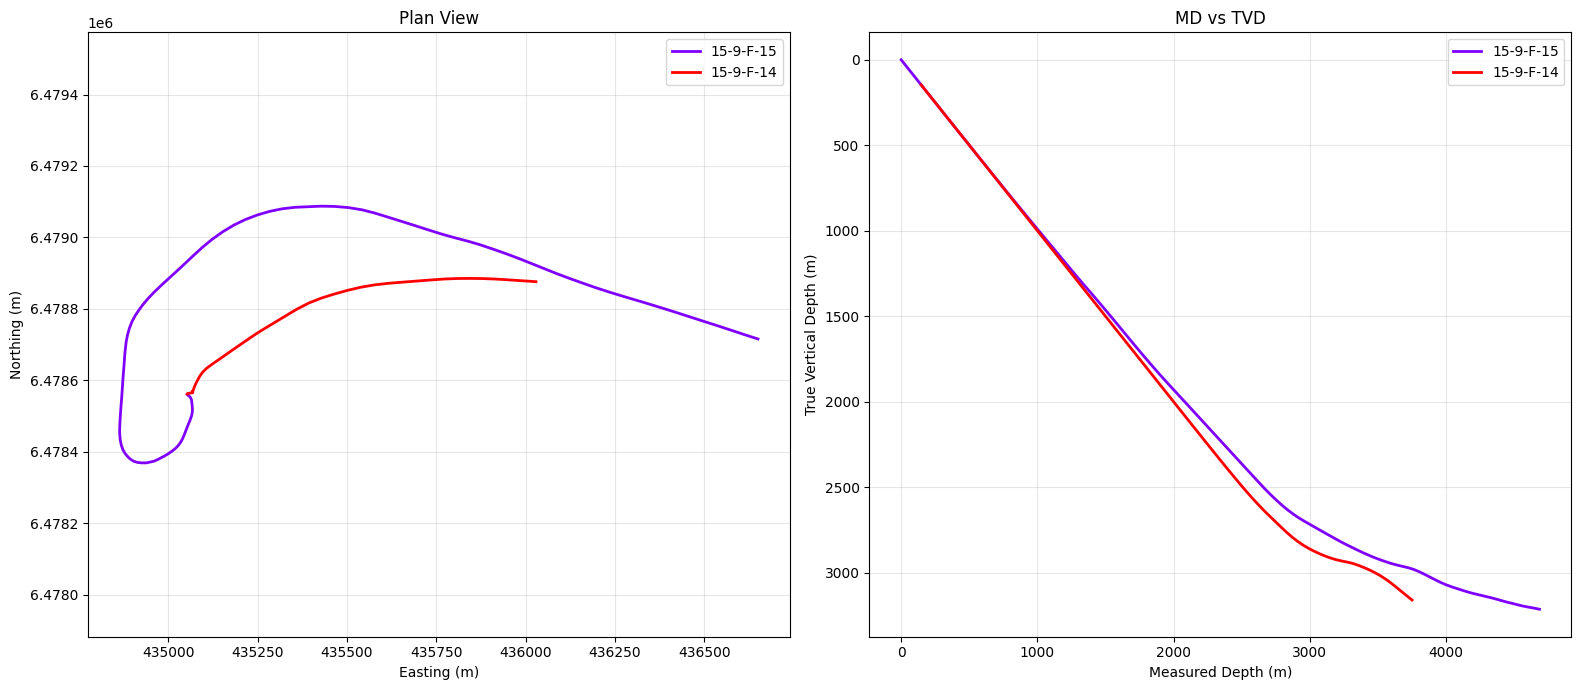

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plan view: Northing vs Easting
for i, ws in enumerate(well_surveys):
    df = ws['survey_df']
    axes[0].plot(df[7], df[6], lw=2, color=color[i], label=ws['well_name'])
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_title('Plan View')
axes[0].axis('equal')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Vertical section: MD vs TVD
for i, ws in enumerate(well_surveys):
    df = ws['survey_df']
    axes[1].plot(df[0], df[3], lw=2, color=color[i], label=ws['well_name'])
axes[1].invert_yaxis()   # depth increases downward
axes[1].set_xlabel('Measured Depth (m)')
axes[1].set_ylabel('True Vertical Depth (m)')
axes[1].set_title('MD vs TVD')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Notes / known limitations

- **Surface-row rounding quirk:** at the very first survey station, several columns legitimately report the same value (e.g. `0,00` for MD, Inclination, and Azimuth simultaneously). Pandas auto-renames duplicate column labels (`0,00`, `0,00.1`, `0,00.2`…) when `tabula` misreads that row as a header. Reconstructing it as data means the renamed labels (with their appended `.1`/`.2`) get parsed instead of the original values, introducing a sub-millimeter rounding error at MD = 0 only. It has no practical effect on the trajectory but is worth knowing about if you need station-zero precision.
- **Report type matters:** always confirm you're pulling the *Survey Report – Geographic* table (has Northing/Easting/Lat/Long columns) rather than the plain *Survey Report* variant, so every well shares the same coordinate reference frame.
- Extend `wells_info` with more Volve wells (F-11, F-10, etc.) the same way — find the right page range per PDF using the text-search approach from Section 2, add an entry, done.